# Retail Data Wrangling and Analytics

In [1]:
# Import modules 
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# Load Data from PSQL into DataFrame

**Setup Docker Containers**

![](https://i.imgur.com/VQrBVBk.jpg)

```
#make sure you have both Jupyter and PSQL docker container running
docker ps

#Attach a bridge network to both containers so they can communicate with each other
docker network create jarvis-net
#this command works on running containers
docker network connect jarvis-net jarvis-jupyter
docker network connect jarvis-net jarvis-psql

#verify both containers are attached to the jarvis-net
docker network inspect trading-net

#Note: instead of using `localhost`, you should use container names as hostnames.
```

**Data Preperation**

- Use [pandas.read_sql](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_sql.html) api to load the PSQL retail table into a Pandas DataFrame

![](https://i.imgur.com/AmkAP63.jpg)

- Get familair with the transaction date with `df.head()`, `df.sample(10)`, `df.info()`, `df.describe()`, etc..



In [2]:
#install psql "driver"
!pip3 install psycopg2-binary

In [2]:
from sqlalchemy import create_engine

In [4]:
#Write your code in one or more cells (please remove this line from your notebook)

engine_string = "postgresql+psycopg2://postgres:postgres123@pg_sql:5432/postgres"
engine = create_engine(engine_string)
retail_df = pd.read_sql_table("retail", engine)
retail_df.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [5]:
retail_df.shape

(1067371, 8)

In [6]:
retail_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column        Non-Null Count    Dtype         
---  ------        --------------    -----         
 0   invoice_no    1067371 non-null  object        
 1   stock_code    1067371 non-null  object        
 2   description   1062989 non-null  object        
 3   quantity      1067371 non-null  int64         
 4   invoice_date  1067371 non-null  datetime64[ns]
 5   unit_price    1067371 non-null  float64       
 6   customer_id   824364 non-null   float64       
 7   country       1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [7]:
pd.options.display.float_format = '{:,.2f}'.format

In [8]:
retail_df.describe()

,quantity,unit_price,customer_id
count,"1,067,371.00","1,067,371.00","824,364.00"
mean,9.94,4.65,"15,324.64"
std,172.71,123.55,"1,697.46"
min,"-80,995.00","-53,594.36","12,346.00"
25%,1.00,1.25,"13,975.00"
50%,3.00,2.10,"15,255.00"
75%,10.00,4.15,"16,797.00"
max,"80,995.00","38,970.00","18,287.00"


In [9]:
retail_df.isna().sum()

invoice_no           0
stock_code           0
description       4382
quantity             0
invoice_date         0
unit_price           0
customer_id     243007
country              0
dtype: int64

In [10]:
raw_df = retail_df.copy()
clean_df = retail_df.copy()

In [11]:
#Checking count of cancelled transactions.
cancelled_count = raw_df["invoice_no"].astype(str).str.startswith("C").sum()
cancelled_count

19494

In [12]:
#Handling Missing Values and removing irrelavant Data

# remove invalid rows (non-sales)
clean_df = clean_df[
    (clean_df["quantity"] > 0) &
    (clean_df["unit_price"] > 0)
]

# keep descriptions for labeling (impute missing)
clean_df["description"] = clean_df["description"].fillna("Unknown Product")

# remove cancellations
clean_df = clean_df[~clean_df["invoice_no"].astype(str).str.startswith("C")]


In [13]:
#Feature Engineering
# revenue
clean_df["revenue"] = clean_df["quantity"] * clean_df["unit_price"]

# month key for trend reporting
clean_df["invoice_month"] = clean_df["invoice_date"].dt.to_period("M").dt.to_timestamp()

In [15]:
#Sanity Check
print("raw rows  :", raw_df.shape[0])
print("clean rows:", clean_df.shape[0])
print("clean revenue total:", clean_df["revenue"].sum())
clean_df.head()

raw rows  : 1067371
clean rows: 1041670
clean revenue total: 20972594.56799999


,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,revenue,invoice_month
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,"13,085.00",United Kingdom,83.40,2009-12-01
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom,81.00,2009-12-01
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom,81.00,2009-12-01
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,"13,085.00",United Kingdom,100.80,2009-12-01
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom,30.00,2009-12-01


In [19]:
# Checking for duplicates
clean_df.duplicated().sum()

33757

In [20]:
# Removing duplicates
clean_df = clean_df.drop_duplicates()

In [24]:
# No Duplicates
clean_df.duplicated().sum()

0

In [25]:
clean_df.shape

(1007913, 10)

In [26]:
clean_df["quantity"].describe(percentiles=[0.95, 0.99, 0.999])

count   1,007,913.00
mean           11.12
std           128.47
min             1.00
50%             4.00
95%            31.00
99%           108.00
99.9%         500.00
max        80,995.00
Name: quantity, dtype: float64

In [27]:
clean_df["revenue"].describe(percentiles=[0.95, 0.99, 0.999])

count   1,007,913.00
mean           20.32
std           205.72
min             0.00
50%            10.08
95%            60.00
99%           184.59
99.9%         841.51
max       168,469.60
Name: revenue, dtype: float64

## KPIs

In [28]:
# 1) Total Revenue (Baseline KPI)

total_revenue = clean_df["revenue"].sum()
total_revenue

20476260.448000006

In [29]:
# 2) Monthly Revenue Trend 

clean_df["invoice_month"] = clean_df["invoice_date"].dt.to_period("M")

monthly_revenue = (
    clean_df
    .groupby("invoice_month", as_index=False)
    .agg(monthly_revenue=("revenue", "sum"))
    .sort_values("invoice_month")
)

monthly_revenue.head()

,invoice_month,monthly_revenue
0,2009-12,"822,483.95"
1,2010-01,"651,155.11"
2,2010-02,"551,504.73"
3,2010-03,"830,915.26"
4,2010-04,"678,875.25"


In [30]:
#Sanity Check for Monthly Revenue
monthly_revenue.tail()

,invoice_month,monthly_revenue
20,2011-08,"757,841.38"
21,2011-09,"1,056,435.19"
22,2011-10,"1,151,263.73"
23,2011-11,"1,503,866.78"
24,2011-12,"637,808.33"


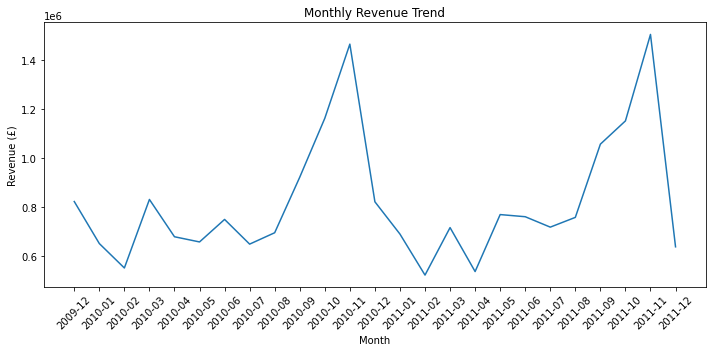

In [31]:
plt.figure(figsize=(10,5))
plt.plot(monthly_revenue["invoice_month"].astype(str),
         monthly_revenue["monthly_revenue"])

plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.tight_layout()
plt.show()

In [32]:
# 3) Average Order Value (AOV)

invoice_df = (
    clean_df
    .groupby("invoice_no", as_index=False)
    .agg(invoice_revenue=("revenue", "sum"))
)

aov = invoice_df["invoice_revenue"].mean()
aov

510.9229844549264

In [33]:
invoice_df["invoice_revenue"].describe()

count    40,077.00
mean        510.92
std       1,482.33
min           0.19
25%         149.75
50%         302.22
75%         493.40
max     168,469.60
Name: invoice_revenue, dtype: float64

In [34]:
#Putting it together in a single df
rev_performance_stability = pd.DataFrame({
    "KPI": ["Total Revenue", "Average Order Value (AOV)"],
    "Value": [total_revenue, aov]
})
rev_performance_stability

,KPI,Value
0,Total Revenue,"20,476,260.45"
1,Average Order Value (AOV),510.92


In [35]:
customer_df = (
    clean_df
    .dropna(subset=["customer_id"])
    .assign(customer_id=lambda df: df["customer_id"].astype(int))
    .groupby("customer_id", as_index=False)
    .agg(
        customer_revenue=("revenue", "sum"),
        invoices=("invoice_no", "nunique")
    )
)

customer_df.head()

,customer_id,customer_revenue,invoices
0,12346,"77,556.46",12
1,12347,"4,921.53",8
2,12348,"2,019.40",5
3,12349,"4,428.69",4
4,12350,334.40,1


In [36]:
# 4) Number of Active Customers
active_customers = customer_df["customer_id"].nunique()
active_customers

5878

In [37]:
# 5) Revenue per customer

revenue_per_customer = (
    customer_df["customer_revenue"].sum() / active_customers
)
revenue_per_customer

2955.9040945899965

In [38]:
# 6) Revenue Concentration (Top 10% Customers)

customer_df_sorted = (
    customer_df
    .sort_values("customer_revenue", ascending=False)
    .reset_index(drop=True)
)

top_n = int(len(customer_df_sorted) * 0.10)

top10_revenue_share = (
    customer_df_sorted.loc[:top_n - 1, "customer_revenue"].sum()
    / customer_df_sorted["customer_revenue"].sum()
)

top10_revenue_share

0.6389520586684515

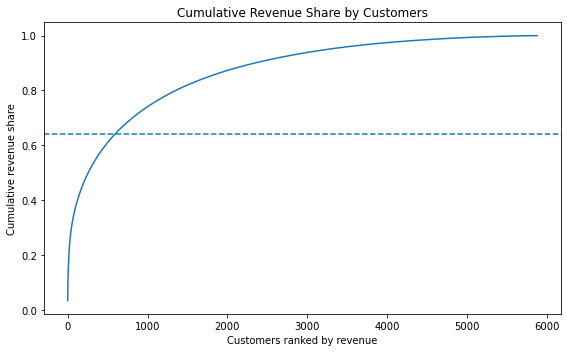

In [39]:
customer_df_sorted["cum_revenue_share"] = (
    customer_df_sorted["customer_revenue"].cumsum()
    / customer_df_sorted["customer_revenue"].sum()
)

plt.figure(figsize=(8,5))
plt.plot(customer_df_sorted["cum_revenue_share"].values)
plt.axhline(0.64, linestyle="--")

plt.title("Cumulative Revenue Share by Customers")
plt.xlabel("Customers ranked by revenue")
plt.ylabel("Cumulative revenue share")
plt.tight_layout()
plt.show()

In [40]:
#Build the RFM Base Table

analysis_date = clean_df["invoice_date"].max() + pd.Timedelta(days=1)

rfm = (
    clean_df
    .dropna(subset=["customer_id"])
    .assign(customer_id=lambda df: df["customer_id"].astype(int))
    .groupby("customer_id", as_index=False)
    .agg(
        monetary=("revenue", "sum"),
        frequency=("invoice_no", "nunique"),
        last_purchase=("invoice_date", "max")
    )
)

rfm["recency"] = (analysis_date - rfm["last_purchase"]).dt.days
rfm.head()

,customer_id,monetary,frequency,last_purchase,recency
0,12346,"77,556.46",12,2011-01-18 10:01:00,326
1,12347,"4,921.53",8,2011-12-07 15:52:00,2
2,12348,"2,019.40",5,2011-09-25 13:13:00,75
3,12349,"4,428.69",4,2011-11-21 09:51:00,19
4,12350,334.40,1,2011-02-02 16:01:00,310


In [41]:
# Create RFM Scores based on Quartiles
rfm["R"] = pd.qcut(rfm["recency"], 4, labels=[4,3,2,1]).astype(int)
rfm["F"] = pd.qcut(rfm["frequency"].rank(method="first"), 4, labels=[1,2,3,4]).astype(int)
rfm["M"] = pd.qcut(rfm["monetary"].rank(method="first"), 4, labels=[1,2,3,4]).astype(int)

rfm["RFM_score"] = rfm["R"] + rfm["F"] + rfm["M"]

In [42]:
# Map RFM Scores to 4 Executive-Friendly Segments

def rfm_segment(score):
    if score >= 10:
        return "High-Value Loyal"
    elif score >= 8:
        return "Frequent / Potential Loyal"
    elif score >= 6:
        return "New / Low Engagement"
    else:
        return "At-Risk / Dormant"

rfm["segment"] = rfm["RFM_score"].apply(rfm_segment)


In [43]:
# 8) Revenue Share by RFM Segment

rfm_summary = (
    rfm
    .groupby("segment", as_index=False)
    .agg(
        customers=("customer_id", "nunique"),
        revenue=("monetary", "sum")
    )
)

rfm_summary["revenue_share"] = (
    rfm_summary["revenue"] / rfm_summary["revenue"].sum()
)

rfm_summary.sort_values("revenue", ascending=False)

,segment,customers,revenue,revenue_share
2,High-Value Loyal,1740,"14,018,171.74",0.81
1,Frequent / Potential Loyal,1186,"1,880,739.14",0.11
3,New / Low Engagement,1216,"967,944.70",0.06
0,At-Risk / Dormant,1736,"507,948.68",0.03


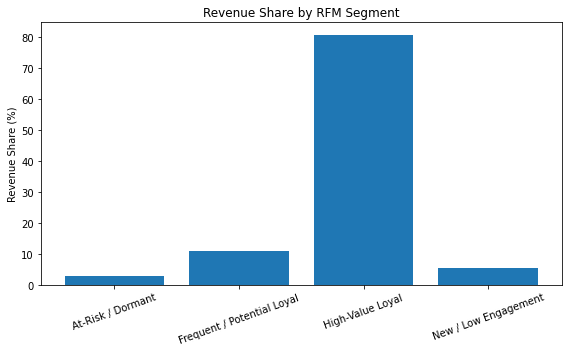

In [44]:
plt.figure(figsize=(8,5))
plt.bar(rfm_summary["segment"], rfm_summary["revenue_share"] * 100)

plt.title("Revenue Share by RFM Segment")
plt.ylabel("Revenue Share (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [45]:
# Building Product Level Data Set

product_df = (
    clean_df
    .groupby(["stock_code", "description"], as_index=False)
    .agg(
        product_revenue=("revenue", "sum"),
        product_volume=("quantity", "sum"),
        invoices=("invoice_no", "nunique")
    )
)

product_df.head()

,stock_code,description,product_revenue,product_volume,invoices
0,10002,INFLATABLE POLITICAL GLOBE,"6,942.26",8671,362
1,10002R,ROBOT PENCIL SHARPNER,20.57,4,3
2,10080,GROOVY CACTUS INFLATABLE,129.29,315,27
3,10109,BENDY COLOUR PENCILS,1.68,4,1
4,10120,DOGGY RUBBER,142.74,664,73


In [46]:
# 9) Top 10 Products by Revenue

top10_products = (
    product_df
    .sort_values("product_revenue", ascending=False)
    .head(10)
)

top10_products

,stock_code,description,product_revenue,product_volume,invoices
5615,M,Manual,"339,226.24",9629,784
1891,22423,REGENCY CAKESTAND 3 TIER,"330,590.32",26478,3918
5614,DOT,DOTCOM POSTAGE,"309,854.11",1415,1415
4999,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"257,546.20",94142,5356
3355,23843,"PAPER CRAFT , LITTLE BIRDIE","168,469.60",80995,1
3716,47566,PARTY BUNTING,"148,318.28",28200,2674
4967,85099B,JUMBO BAG RED RETROSPOT,"145,961.83",77280,3245
4640,84879,ASSORTED COLOUR BIRD ORNAMENT,"129,324.49",80082,2807
5617,POST,POSTAGE,"125,682.42",5363,1851
1477,22086,PAPER CHAIN KIT 50'S CHRISTMAS,"117,760.29",35084,2018


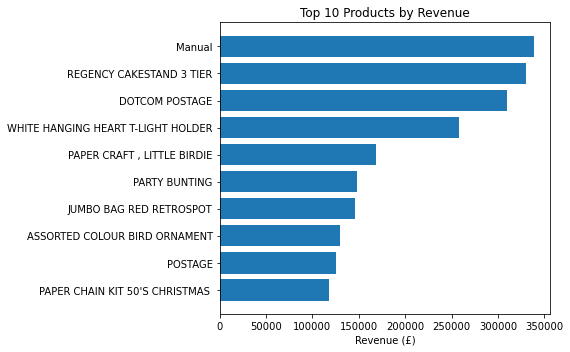

In [47]:
plt.figure(figsize=(8,5))
plt.barh(top10_products["description"],
         top10_products["product_revenue"])

plt.gca().invert_yaxis()
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (£)")
plt.tight_layout()
plt.show()

In [48]:
# 10) Revenue vs Volume

product_df[["product_revenue", "product_volume"]].describe()

,product_revenue,product_volume
count,"5,630.00","5,630.00"
mean,"3,636.99","1,990.26"
std,"11,628.26","5,100.79"
min,0.02,1.00
25%,189.56,77.00
50%,916.12,471.00
75%,"3,043.95","1,817.75"
max,"339,226.24","106,139.00"


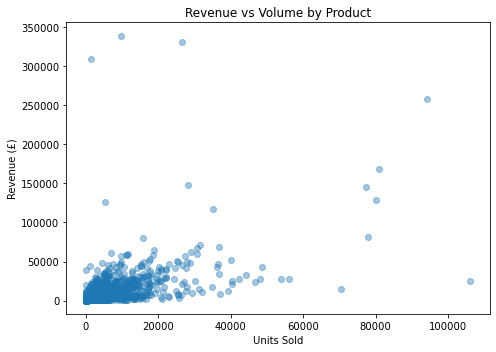

In [49]:
plt.figure(figsize=(7,5))
plt.scatter(product_df["product_volume"],
            product_df["product_revenue"],
            alpha=0.4)

plt.title("Revenue vs Volume by Product")
plt.xlabel("Units Sold")
plt.ylabel("Revenue (£)")
plt.tight_layout()
plt.show()

In [50]:
# Build Country-Level Revenue Table

country_df = (
    clean_df
    .groupby("country", as_index=False)
    .agg(country_revenue=("revenue", "sum"))
    .sort_values("country_revenue", ascending=False)
)

country_df.head(10)

,country,country_revenue
40,United Kingdom,"17,410,196.12"
11,EIRE,"658,767.31"
26,Netherlands,"554,038.09"
15,Germany,"425,019.71"
14,France,"350,456.09"
0,Australia,"169,283.46"
34,Spain,"108,332.49"
36,Switzerland,"100,685.59"
35,Sweden,"91,869.82"
10,Denmark,"68,580.69"


In [51]:
# 11) Revenue by Country (Top 5)

top5_countries = country_df.head(5)
top5_countries

,country,country_revenue
40,United Kingdom,"17,410,196.12"
11,EIRE,"658,767.31"
26,Netherlands,"554,038.09"
15,Germany,"425,019.71"
14,France,"350,456.09"


In [52]:
# 12) Country Revenue Share

country_df["revenue_share"] = (
    country_df["country_revenue"] / country_df["country_revenue"].sum()
)

country_df.head(10)

,country,country_revenue,revenue_share
40,United Kingdom,"17,410,196.12",0.85
11,EIRE,"658,767.31",0.03
26,Netherlands,"554,038.09",0.03
15,Germany,"425,019.71",0.02
14,France,"350,456.09",0.02
0,Australia,"169,283.46",0.01
34,Spain,"108,332.49",0.01
36,Switzerland,"100,685.59",0.00
35,Sweden,"91,869.82",0.00
10,Denmark,"68,580.69",0.00


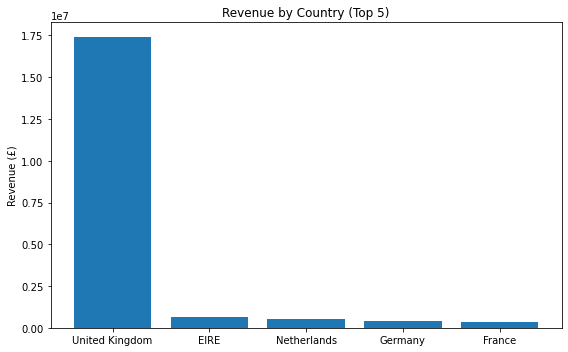

In [53]:
plt.figure(figsize=(8,5))
plt.bar(top5_countries["country"],
        top5_countries["country_revenue"])

plt.title("Revenue by Country (Top 5)")
plt.ylabel("Revenue (£)")
plt.tight_layout()
plt.show()

# Load CSV into Dataframe
Alternatively, the LGS IT team also dumped the transactional data into a [CSV file](https://raw.githubusercontent.com/jarviscanada/jarvis_data_eng_demo/feature/data/python_data_wrangling/data/online_retail_II.csv). However, the CSV header (column names) doesn't follow the snakecase or camelcase naming convention (e.g. `Customer ID` instead of `customer_id` or `CustomerID`). As a result, you will need to use Pandas to clean up the data before doing any analytics. In addition, unlike the PSQL scheme, CSV files do not have data types associated. Therefore, you will need to cast/convert certain columns into correct data types (e.g. DateTime, numbers, etc..)

**Data Preperation**

- Read the `data/online_retail_II.csv` file into a DataFrame
- Rename all columns to upper camelcase or snakecase
- Convert/cast all columns to the appropriate data types (e.g. datetime)

In [ ]:
retail_df = pd.read_csv
retail_df.head()

# Total Invoice Amount Distribution

---
**Please remove this insturction cell after you are done with coding**

1. Calculate the invoice amount. Note: an invoice consists of one or more items where each item is a row in the df. (hint: you need to `GROUP BY invoice`)
2. Draw the distribution of invoice amount with min, max, median, mod, and mean. However, you will notice many outlier data (e.g. invoices with large amounts). Sample hist and box charts:

![](https://i.imgur.com/N8hsbDa.jpg)

3. Draw the distribution for the first 85 quantiles of the invoice amount data with min, max, median, mod, and mean.


![](https://i.imgur.com/tJrH1qj.jpg)


---

In [ ]:
# Write your code in one or more cells (please remove this line from your notebook)


# Monthly Placed and Canceled Orders

---
**Please remove this insturction cell after you are done with coding**

- The attribute information (see the `project kick-off` section) contains useful information that helps you to identify canceled orders
- To simplify the problem, you can assume that there are two invoice numbers for each canceled order (one for the original invoice and one for the canceled invoice). Therefore, `# of placed orders = total # of orders - 2 * canceled order`. Furthermore, you can also assume the original invoice and canceled invoice are on always on the same day (this eliminate the case where the original invoice and canceled invoices are on different months)
- hints: you might want to create a new integer column with YYYYMM format. e.g. `2009-12-01 07:45:00 -> 200912` which allows easy GROUP BY.

**Sample Plot:**

![](https://i.imgur.com/tmLsPDf.jpg)

---

# Monthly Sales

---
**Please remove this insturction cell after you are done with coding**


- Calculate the monthly sales data
- Plot a chart to show monthly sales (e.g. x-asix=year_month, y-axis=sales_amount)

![](https://i.imgur.com/k1KOqKO.jpg)

---

# Monthly Sales Growth


---
**Please remove this insturction cell after you are done with coding**

- Calculate monthly sales percentage growth data
- Plot a chart to show the growth percentage

![](https://i.imgur.com/J3btp8j.jpg)

---

# Monthly Active Users

---
**Please remove this insturction cell after you are done with coding**

- Compute # of active users (e.g. unique `CusotomerID`) for each month
- Plot a bar chart

![](https://i.imgur.com/eFYp8VF.jpg)

---

# New and Existing Users



---
**Please remove this insturction cell after you are done with coding**

- Plot a diagram to show new and exiting user for each month.
- A user is identified as a new user when he/she makes the first purchase
- A user is identified as an existing user when he/she made purchases in the past
- hints:
  - find out the first purchase year-month for each user and then join this data with the transactional data to help you identified new/exiting users

![](https://i.imgur.com/nWjnrpr.jpg)

---

## Finding RFM

RFM is a method used for analyzing customer value. It is commonly used in database marketing and direct marketing and has received particular attention in the retail and professional services industries. ([wikipedia](https://en.wikipedia.org/wiki/RFM_(market_research)))

Optional Reading: [Making Your Database Pay Off Using Recency Frequency and Monetary Analysis](http://www.dbmarketing.com/2010/03/making-your-database-pay-off-using-recency-frequency-and-monetary-analysis/)


RFM stands for three dimensions:

- Recency – How recently did the customer purchase?

- Frequency – How often do they purchase?

- Monetary Value – How much do they spend?

Note: To simplify the problem, let's keep all placed and canceled orders.


**Sample RFM table**

![](https://i.imgur.com/sXFIg6u.jpg)

# RFM Segmentation

---
**Please remove this insturction cell after you are done with coding**
RFM segmentation categorizes your customers into different segments, according to their interactions with your website, which will allow you to subsequently approach these groups in the most effective way. In this article, we will show you how to make an RFM segmentation based on an RFM score combining all three RFM parameters together and allowing you to divide your customers into 11 different segments. 

- [RFM Segmentation business cases](https://docs.exponea.com/docs/rfm-segmentation-business-use)

- [RFM Segmentation Guide](https://docs.exponea.com/docs/rfm-segmentation-business-use)

As you can see, computing RFM segmentation requires extensive domain knowledge in marketing which is out of the scope in this project. In practice, you will work with BA/DA to figure out how to compute RFM segments. To simplify this project, a [sample RFM segmentation Notebook](https://github.com/jarviscanada/jarvis_data_eng_demo/blob/feature/data/python_data_wrangling/ipynb/customer-segmentation-with-rfm-score.ipynb) is provided. You are responsible to understand everything from that Notebook and then integrate it into yours. 

- Download the [sample notebook](https://github.com/jarviscanada/jarvis_data_eng_demo/blob/feature/data/python_data_wrangling/ipynb/customer-segmentation-with-rfm-score.ipynb) and import to your Jupyter Notebook or VSCode
- Run the notebook and understand all cells
- Read the remark section at the end of the notebook. You will need this information when writing the README file
- Integrate the RFM segmentation calculation into your notebook

---